In [38]:
import pandas as pd
df = pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\books 5.csv')
df.head(5)

,asin,reviewText,overall,category,summary
0,0001713353,"The King, the Mice and the Cheese by Nancy Gur...",5.0,Books_5,A story children will love and learn from
1,0001713353,The kids loved it!,5.0,Books_5,Five Stars
2,0001713353,My students (3 & 4 year olds) loved this book!...,5.0,Books_5,Five Stars
3,0001713353,LOVE IT,5.0,Books_5,Five Stars
4,0001713353,Great!,5.0,Books_5,Five Stars


In [39]:
df.tail(5)

,asin,reviewText,overall,category,summary
3976643,0312950489,I just read the latest Bosch novel and decided...,5.0,Books_5,Incredible to read
3976644,0312950489,Good book for a cold night. Surprising end to ...,3.0,Books_5,good read
3976645,0312950489,Thanks!!,5.0,Books_5,Five Stars
3976646,0312950489,"Just ok, Nothing special.",3.0,Books_5,Three Stars
3976647,0312950489,Hard to get into but really good.,4.0,Books_5,Four Stars


In [40]:
df.shape

(3976648, 5)

In [41]:
df.sample(5)

,asin,reviewText,overall,category,summary
2891612,0241280974,One of the best books I have read lately. The...,5.0,Books_5,Well worth it....
3640438,0312145381,Love M. C. Beaton books. Her characters are o...,5.0,Books_5,Enjoyed Story
1669568,0091923530,so far so good!,4.0,Books_5,Four Stars
533164,0060080841,Very fun book to read after watching both the ...,4.0,Books_5,Very fun book to read after watching both the ...
3715660,0312352387,"Imagine Emma Bovary, even dumber and greedier ...",3.0,Books_5,Saturday wife -- so so.


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3976648 entries, 0 to 3976647
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   asin        object 
 1   reviewText  object 
 2   overall     float64
 3   category    object 
 4   summary     object 
dtypes: float64(1), object(4)
memory usage: 151.7+ MB


In [43]:
df.columns

Index(['asin', 'reviewText', 'overall', 'category', 'summary'], dtype='object')

Rating Distribution

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


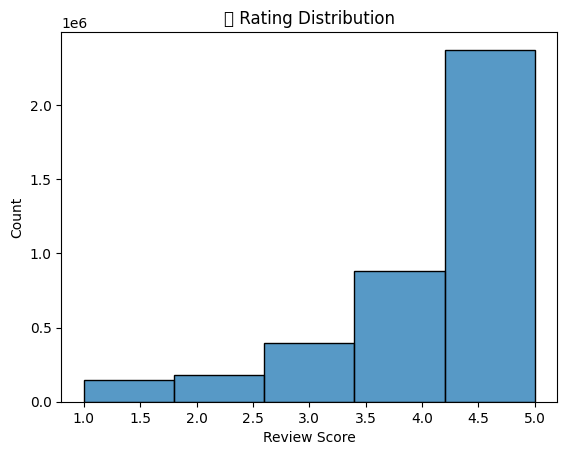

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['overall'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Review Length vs. Rating

In [45]:
pip install boxplot

Note: you may need to restart the kernel to use updated packages.


C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


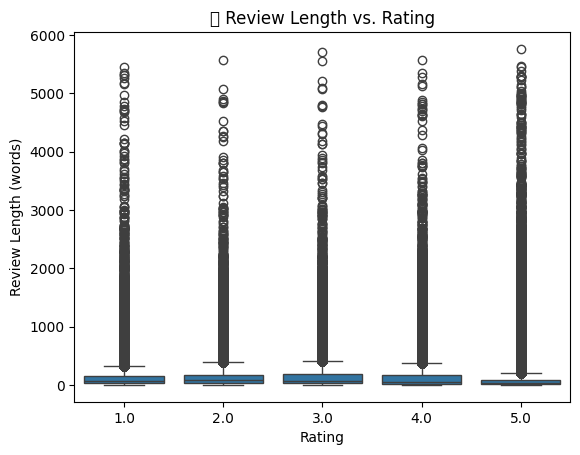

In [46]:
df['length'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='overall', y='length')
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()


Category-Level Rating Trends

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


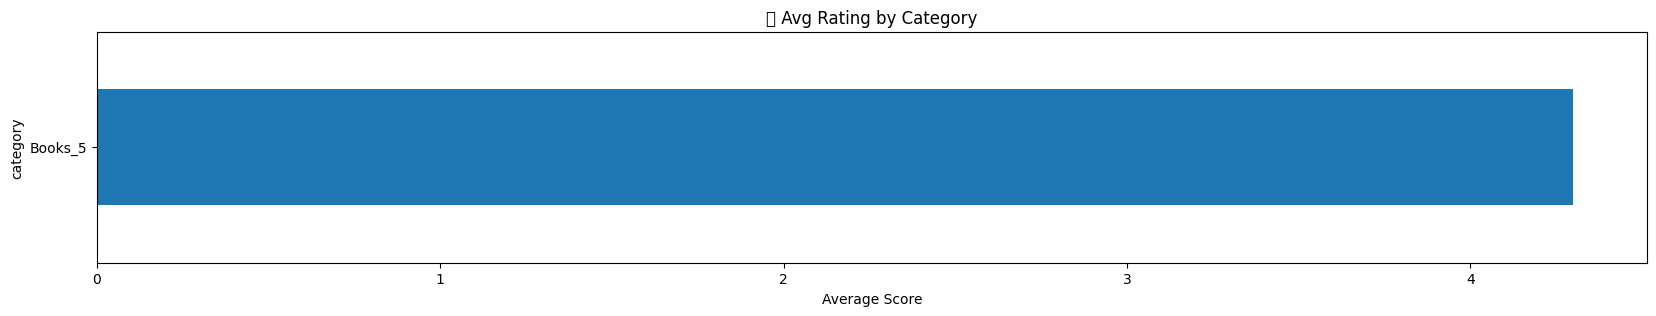

In [47]:
category_avg = df.groupby('category')['overall'].mean().sort_values()
category_avg.plot(kind='barh', figsize=(20, 3), title="📚 Avg Rating by Category")
plt.xlabel("Average Score")
plt.show()


In [48]:
df.drop(columns=['asin',  'category', 'summary'],inplace=True)

In [49]:
df.columns

Index(['reviewText', 'overall', 'length'], dtype='object')

In [50]:
df.isnull().sum()

reviewText    131
overall         0
length          0
dtype: int64

In [51]:
df.dropna(inplace=True)

In [52]:
df.isnull().sum()

reviewText    0
overall       0
length        0
dtype: int64

In [53]:
df.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

In [54]:
df.head(5)

,review,rating,length
0,"The King, the Mice and the Cheese by Nancy Gur...",5.0,162
1,The kids loved it!,5.0,4
2,My students (3 & 4 year olds) loved this book!...,5.0,16
3,LOVE IT,5.0,2
4,Great!,5.0,1


In [55]:
print(df.duplicated().sum())

234551


In [56]:
df.drop_duplicates(subset=['review','rating'],inplace=True)

In [57]:
print(df.duplicated().sum())

0


In [58]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [59]:
df['rating']=df['rating'].astype(int)

In [60]:
df['rating'].value_counts()

rating
5    2190039
4     849541
3     385172
2     176563
1     140651
Name: count, dtype: int64

In [61]:
df.shape

(3741966, 3)

In [62]:
df.sample(5)

,review,rating,length
156152,read the book in anticipation of the novel and...,5,18
711406,the story made me want to move to alaska too i...,5,30
3869615,woolf has written a good biography that tackle...,4,105
3906214,after a bit of a slow start rd party narrative...,4,46
3169043,this was a riveting book and a wonderfully wri...,4,231


In [63]:
df.to_csv('D-BOOKS - 5 DL.csv',index=False)